In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import logging
import time
import jax
import jax.numpy as jnp
import gc
# Disable JAX preallocation
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"


In [2]:
# -----------------------------
# Setup
# -----------------------------
location = "phoenix"
opt_method = "gradient_ascent"

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logging.info("Starting gradient ascent optimization script...")


2026-06-03 14:55:35,492 - INFO - Starting gradient ascent optimization script...


In [3]:

# -----------------------------
# User parameters
# -----------------------------
rotation_angle = 180.0
CE_value = 0.84             # conversion efficiency
NOCT_value = 48.0

thickness_range = np.arange(10.0, 250.0, 10.0) # np.arange(100.0, 320.0, 20.0)
tilt_angles = np.arange(0.0, 50.0, 10.0)

initial_lr_tilt = 10.0
decay_rate_tilt = 0.05
initial_lr_thickness = 50.0
decay_rate_thickness = 0.1
num_steps = 30
min_tilt, max_tilt = 0.0, 90.0
min_thickness, max_thickness = 10.0, 250.0 # 100.0, 300.0

In [4]:
sys.path.append(os.path.join(os.getcwd(), "src"))

In [5]:

# -----------------------------
# Load irradiance and models
# -----------------------------
sys.path.append(os.path.join(os.getcwd(), "src")) # Jupyter notebook version

from SolDi2T.energy_yield.irradiance import trim_irradiance, get_irradiance_data
from SolDi2T.energy_yield.jsc_calculation import JscCalc_jax
from SolDi2T.optics.interpolate_absorption import (
    AbsorptionSurfaceModel,
    load_absorption_surface_model,
    predict_absorption_surface_NN,
)
from SolDi2T.electrics.model_utils import MultiOutputNN, load_model

get_irradiance_data()
# Load irradiance
with open(f"data/irradiance/{location}_irradiance_data.pkl", "rb") as file:
    irradiance = pickle.load(file)

lambda_ = jnp.arange(300, 1201, 1)
lambda_values = irradiance["Irr_spectra_clouds_wavelength"].flatten()
thetasun = irradiance["Data_TMY3"]["Data_TMY3"][:, 6]
phisun = irradiance["Data_TMY3"]["Data_TMY3"][:, 7]
IrradianceDifH = irradiance["Irr_spectra_clouds_diffuse_horizontal"]
IrradianceDirH = irradiance["Irr_spectra_clouds_direct_horizontal"]
TempAmbient = irradiance["Data_TMY3"]["Data_TMY3"][:, 13]

IrradianceDifN = IrradianceDifH / jnp.pi
IrradianceDirN = (jnp.ceil(thetasun) < 90)[:, None] * IrradianceDirH / jnp.abs(
    jnp.cos(jnp.deg2rad(thetasun))
)[:, None]

IdifN = trim_irradiance(lambda_, IrradianceDifN, lambda_values)
IdirN = trim_irradiance(lambda_, IrradianceDirN, lambda_values)

# Load models
loaded_absorption_surface_model, loaded_absorption_surface_params, loaded_absorption_surface_scaler_X = load_absorption_surface_model(
    "data/absorption/absorption_surface_model.pkl"
)
model = MultiOutputNN()
loaded_params, loaded_scaler_X, loaded_scaler_voc, loaded_scaler_jsc, loaded_scaler_ff = load_model(
    "data/electrics/drift_diffusion_nn_model.pkl"
)

# -----------------------------
# Output directory
# -----------------------------
output_dir = os.path.join("data", "results", location)
os.makedirs(output_dir, exist_ok=True)


INFO:2026-06-03 14:55:37,201:jax._src.xla_bridge:924: Unable to initialize backend 'cuda': 
2026-06-03 14:55:37,201 - INFO - Unable to initialize backend 'cuda': 
INFO:2026-06-03 14:55:37,202:jax._src.xla_bridge:924: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2026-06-03 14:55:37,202 - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2026-06-03 14:55:37,203:jax._src.xla_bridge:924: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2026-06-03 14:55:37,203 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2026-06-03 14:55:37,204 - WARNING - An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Files already exist. Skipping download.


In [6]:
np.arange(10.0, 250.0, 10.0) 

array([ 10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100., 110.,
       120., 130., 140., 150., 160., 170., 180., 190., 200., 210., 220.,
       230., 240.])

In [7]:
thickness_range[19]

np.float64(200.0)

In [8]:
# -----------------------------
# Energy yield wrapper
# -----------------------------
A = predict_absorption_surface_NN(thickness_range[9],loaded_absorption_surface_model,
                                  loaded_absorption_surface_params,loaded_absorption_surface_scaler_X,)
print('A', A, type(A))
print("A shape:", A.shape)
print("len(A):", len(A)) 

A [[[0.1323884  0.14124991 0.14373225 ... 0.20901974 0.21147302 0.21308117]
  [0.1420275  0.14007133 0.13820162 ... 0.19765383 0.20666277 0.20298198]
  [0.130116   0.13983099 0.1431373  ... 0.21237329 0.21000628 0.20985146]
  ...
  [0.05515874 0.05792365 0.05496874 ... 0.0346469  0.02277177 0.03328276]
  [0.04056545 0.04744578 0.03033755 ... 0.0218495  0.0249829  0.01487355]
  [0.02100192 0.02955069 0.02282781 ... 0.0068611  0.00765242 0.01199478]]] <class 'jaxlib.xla_extension.ArrayImpl'>
A shape: (1, 90, 901)
len(A): 1


[0.1323884  0.14124991 0.14373225 0.14494619 0.16909076 0.16713658
 0.17645007 0.17749844 0.19132952 0.18499379 0.20141369 0.20990282
 0.21110669 0.21887684 0.23040624 0.2274541  0.23928548 0.24106431
 0.24787629 0.25002488 0.27245623 0.25789845 0.26261598 0.26107898
 0.2688614  0.27161783 0.26177064 0.27057344 0.2742857  0.26730543
 0.26791358 0.27013958 0.27705085 0.27461582 0.2671986  0.26985276
 0.26852733 0.27151597 0.28418204 0.27706325 0.27164173 0.27118883
 0.27496657 0.2774178  0.28609306 0.2666428  0.2855254  0.2919019
 0.289206   0.29145008 0.290867   0.28817508 0.29252827 0.29619926
 0.29337412 0.2979701  0.29875785 0.3068985  0.3008367  0.30014727
 0.29051623 0.3101     0.30376804 0.320069   0.32564566 0.33230782
 0.3278784  0.32964712 0.33687735 0.33860973 0.34299973 0.3486554
 0.3537892  0.35715267 0.3576827  0.36042207 0.3725718  0.38235074
 0.37796426 0.38280234 0.37176007 0.38294291 0.38982263 0.3891599
 0.4013385  0.38896522 0.39904878 0.40488395 0.40516624 0.4012194

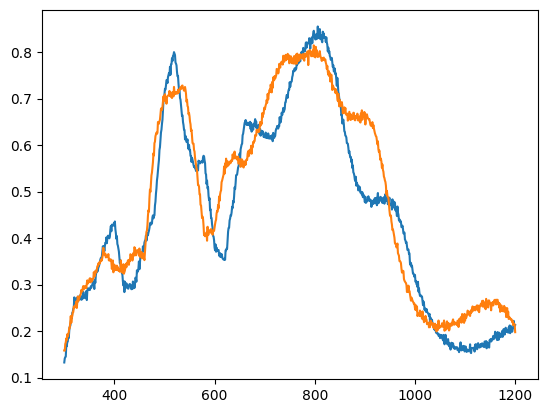

In [9]:
print(A[0, 0]) # does not change over thickness? 
plt.plot(lambda_, A[0, 0])
plt.plot(lambda_, A[0, 30])

In [10]:
print(A[0, 0]) # does change over thickness. could be unitless absorption in active material, A coeff, R coeff, T coeff. 

[0.1323884  0.14124991 0.14373225 0.14494619 0.16909076 0.16713658
 0.17645007 0.17749844 0.19132952 0.18499379 0.20141369 0.20990282
 0.21110669 0.21887684 0.23040624 0.2274541  0.23928548 0.24106431
 0.24787629 0.25002488 0.27245623 0.25789845 0.26261598 0.26107898
 0.2688614  0.27161783 0.26177064 0.27057344 0.2742857  0.26730543
 0.26791358 0.27013958 0.27705085 0.27461582 0.2671986  0.26985276
 0.26852733 0.27151597 0.28418204 0.27706325 0.27164173 0.27118883
 0.27496657 0.2774178  0.28609306 0.2666428  0.2855254  0.2919019
 0.289206   0.29145008 0.290867   0.28817508 0.29252827 0.29619926
 0.29337412 0.2979701  0.29875785 0.3068985  0.3008367  0.30014727
 0.29051623 0.3101     0.30376804 0.320069   0.32564566 0.33230782
 0.3278784  0.32964712 0.33687735 0.33860973 0.34299973 0.3486554
 0.3537892  0.35715267 0.3576827  0.36042207 0.3725718  0.38235074
 0.37796426 0.38280234 0.37176007 0.38294291 0.38982263 0.3891599
 0.4013385  0.38896522 0.39904878 0.40488395 0.40516624 0.4012194

In [11]:
0.37459741107352257 

0.37459741107352257

In [12]:
import numpy as np
import pickle

with open("data/absorption/absorption_surface_model.pkl", "rb") as f:
    data = pickle.load(f)

loaded_absorption_surface_model = data['model']
loaded_absorption_surface_params = data['params']
loaded_absorption_surface_scaler_X = data['scaler_X']

from SolDi2T.optics.interpolate_absorption import predict_absorption_surface_NN

A = predict_absorption_surface_NN(
    100.0,
    loaded_absorption_surface_model,
    loaded_absorption_surface_params,
    loaded_absorption_surface_scaler_X,
)

print("A.shape:", A.shape)
print("A[0, 0, :]")   # angle=0°, all wavelengths
print(A[0, 0, :])
print("A[0, :, 0]")   # all angles, wavelength=300nm
print(A[0, :, 0])

A.shape: (1, 90, 901)
A[0, 0, :]
[0.1323884  0.14124991 0.14373225 0.14494619 0.16909076 0.16713658
 0.17645007 0.17749844 0.19132952 0.18499379 0.20141369 0.20990282
 0.21110669 0.21887684 0.23040624 0.2274541  0.23928548 0.24106431
 0.24787629 0.25002488 0.27245623 0.25789845 0.26261598 0.26107898
 0.2688614  0.27161783 0.26177064 0.27057344 0.2742857  0.26730543
 0.26791358 0.27013958 0.27705085 0.27461582 0.2671986  0.26985276
 0.26852733 0.27151597 0.28418204 0.27706325 0.27164173 0.27118883
 0.27496657 0.2774178  0.28609306 0.2666428  0.2855254  0.2919019
 0.289206   0.29145008 0.290867   0.28817508 0.29252827 0.29619926
 0.29337412 0.2979701  0.29875785 0.3068985  0.3008367  0.30014727
 0.29051623 0.3101     0.30376804 0.320069   0.32564566 0.33230782
 0.3278784  0.32964712 0.33687735 0.33860973 0.34299973 0.3486554
 0.3537892  0.35715267 0.3576827  0.36042207 0.3725718  0.38235074
 0.37796426 0.38280234 0.37176007 0.38294291 0.38982263 0.3891599
 0.4013385  0.38896522 0.3990487

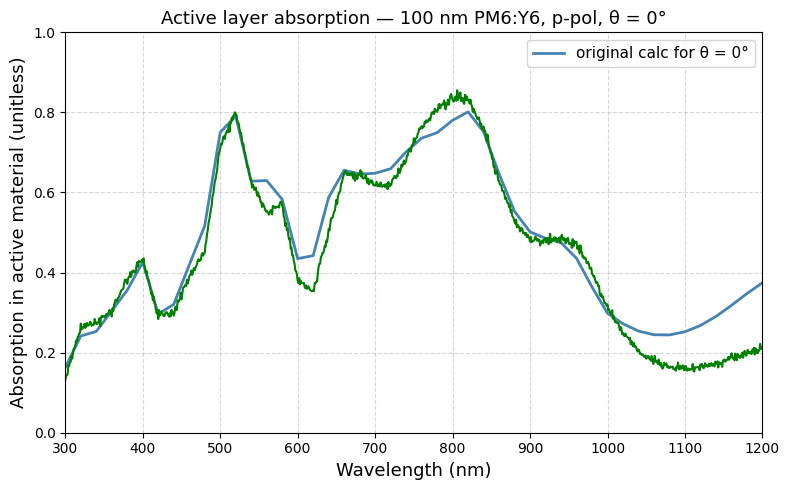

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# ── Load data ──────────────────────────────────────────────────────────────
df = pd.read_csv("100nmPM6Y6_p_11Sept_2025.csv")

# ── Filter to theta = 0° ───────────────────────────────────────────────────
df_theta0 = df[df["theta [deg]"] == 0].copy()

# ── Convert wavelength from um to nm, sort ascending ──────────────────────
df_theta0["wavelength_nm"] = df_theta0["vacuum wavelength [um]"] * 1000
df_theta0 = df_theta0.sort_values("wavelength_nm")

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    df_theta0["wavelength_nm"],
    df_theta0["absorption in active material [unitless]"],
    color="steelblue",
    linewidth=2,
    label="original calc for θ = 0°",
)

ax.set_xlabel("Wavelength (nm)", fontsize=13)
ax.set_ylabel("Absorption in active material (unitless)", fontsize=13)
ax.set_title("Active layer absorption — 100 nm PM6:Y6, p-pol, θ = 0°", fontsize=13)
ax.set_xlim(300, 1200)
ax.set_ylim(0, 1)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)

ax.plot(lambda_, A[0, 0], 'green', label="NN for θ = 0°")

fig.tight_layout()
# fig.savefig("absorption_p_theta0.pdf")
# fig.savefig("absorption_p_theta0.png", dpi=150)
plt.show()
# print("Saved: absorption_p_theta0.pdf / .png")

In [14]:
print(len(A[0, 0]), len(df_theta0["absorption in active material [unitless]"]))

901 46


In [15]:
A = predict_absorption_surface_NN(thickness_range[19],loaded_absorption_surface_model,
                                  loaded_absorption_surface_params,loaded_absorption_surface_scaler_X,)
print('A', A, type(A))
print("A shape:", A.shape)
print("len(A):", len(A)) 
print(thickness_range[19])

A [[[0.21136326 0.21516128 0.2340036  ... 0.11223753 0.13283646 0.12426738]
  [0.21414089 0.2065249  0.23816472 ... 0.11969388 0.12804975 0.11926907]
  [0.20676993 0.21420018 0.23521529 ... 0.11019915 0.10810582 0.12818943]
  ...
  [0.0800356  0.06695126 0.07810216 ... 0.05403107 0.04943858 0.05509985]
  [0.06073646 0.05379101 0.05129388 ... 0.03467016 0.03414626 0.03147999]
  [0.02832433 0.03814103 0.02741484 ... 0.02134746 0.0082005  0.00769553]]] <class 'jaxlib.xla_extension.ArrayImpl'>
A shape: (1, 90, 901)
len(A): 1
200.0


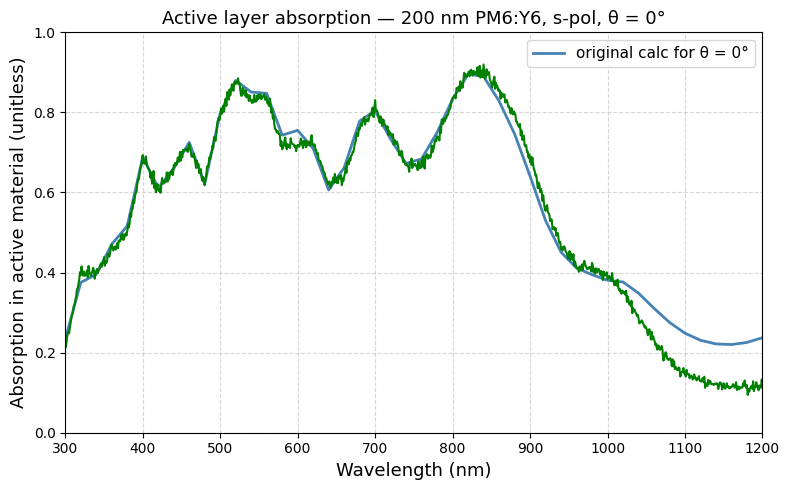

In [16]:

# ── Load data ──────────────────────────────────────────────────────────────
df = pd.read_csv("200nmPM6Y6_s_11Sept_2025.csv")

# ── Filter to theta = 0° ───────────────────────────────────────────────────
df_theta0 = df[df["theta [deg]"] == 0].copy()

# ── Convert wavelength from um to nm, sort ascending ──────────────────────
df_theta0["wavelength_nm"] = df_theta0["vacuum wavelength [um]"] * 1000
df_theta0 = df_theta0.sort_values("wavelength_nm")

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    df_theta0["wavelength_nm"],
    df_theta0["absorption in active material [unitless]"],
    color="steelblue",
    linewidth=2,
    label="original calc for θ = 0°",
)

ax.set_xlabel("Wavelength (nm)", fontsize=13)
ax.set_ylabel("Absorption in active material (unitless)", fontsize=13)
ax.set_title("Active layer absorption — 200 nm PM6:Y6, s-pol, θ = 0°", fontsize=13)
ax.set_xlim(300, 1200)
ax.set_ylim(0, 1)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)

ax.plot(lambda_, A[0, 0], 'green', label="NN for θ = 0°")

fig.tight_layout()
# fig.savefig("absorption_p_theta0.pdf")
# fig.savefig("absorption_p_theta0.png", dpi=150)
plt.show()
# print("Saved: absorption_p_theta0.pdf / .png")

In [17]:
np.arange(100.0, 250.0, 1000.0) 

array([100.])

In [18]:
from scipy.interpolate import interp1d

# ── 1. Load CSV (here using s-pol; swap for p-pol or average as needed) ────
df = pd.read_csv("200nmPM6Y6_s_11Sept_2025.csv")

# ── 2. Build the (90, 901) absorption grid ─────────────────────────────────
lambda_nn = np.arange(300, 1201, 1)  # 901 points, 1 nm steps

A_grid = np.zeros((90, 901))

for angle in range(90):
    df_angle = df[df["theta [deg]"] == angle].copy()
    df_angle["wavelength_nm"] = df_angle["vacuum wavelength [um]"] * 1000
    df_angle = df_angle.sort_values("wavelength_nm")

    wl_csv  = df_angle["wavelength_nm"].values
    abs_csv = df_angle["absorption in active material [unitless]"].values

    # Interpolate from 46 CSV points onto 901-point NN grid
    f = interp1d(wl_csv, abs_csv, kind="linear",
                 bounds_error=False, fill_value="extrapolate")
    A_grid[angle, :] = f(lambda_nn)

# ── 3. Add batch dimension → (1, 90, 901) ─────────────────────────────────
A_new = A_grid[np.newaxis, :, :]  # shape (1, 90, 901)

print("shape A (og) :", np.shape(A))      # (1, 90, 901)
print("shape A (new):", np.shape(A_new))  # (1, 90, 901)

shape A (og) : (1, 90, 901)
shape A (new): (1, 90, 901)


In [19]:
print(" A (og) :",A)      # (1, 90, 901)
print(" A (new):",A_new)  # (1, 90, 901)

 A (og) : [[[0.21136326 0.21516128 0.2340036  ... 0.11223753 0.13283646 0.12426738]
  [0.21414089 0.2065249  0.23816472 ... 0.11969388 0.12804975 0.11926907]
  [0.20676993 0.21420018 0.23521529 ... 0.11019915 0.10810582 0.12818943]
  ...
  [0.0800356  0.06695126 0.07810216 ... 0.05403107 0.04943858 0.05509985]
  [0.06073646 0.05379101 0.05129388 ... 0.03467016 0.03414626 0.03147999]
  [0.02832433 0.03814103 0.02741484 ... 0.02134746 0.0082005  0.00769553]]]
 A (new): [[[0.23343499 0.24053339 0.24763178 ... 0.23615139 0.23674258 0.23733376]
  [0.23343053 0.2405232  0.24761588 ... 0.23619427 0.23678674 0.2373792 ]
  [0.23341841 0.24049381 0.24756921 ... 0.23632348 0.23691978 0.23751608]
  ...
  [0.07481792 0.07371946 0.07262101 ... 0.02603241 0.02594379 0.02585517]
  [0.05256526 0.05175422 0.05094318 ... 0.01741702 0.01735826 0.0172995 ]
  [0.02778601 0.02733552 0.02688503 ... 0.00874377 0.00871432 0.00868486]]]


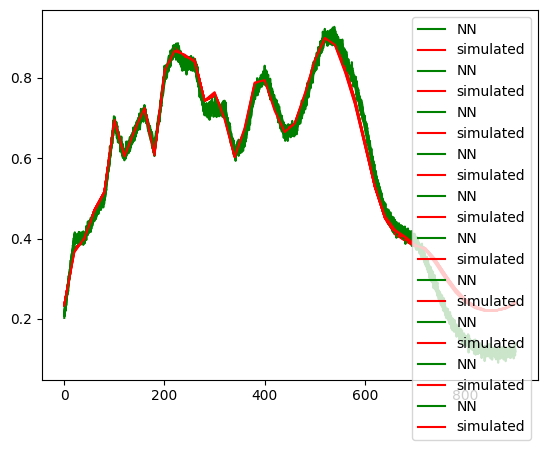

In [20]:
for i in range(0,10):
    plt.plot(A[0, i], 'green', label="NN")
    plt.plot(A_new[0, i], 'red', label="simulated")

plt.legend()

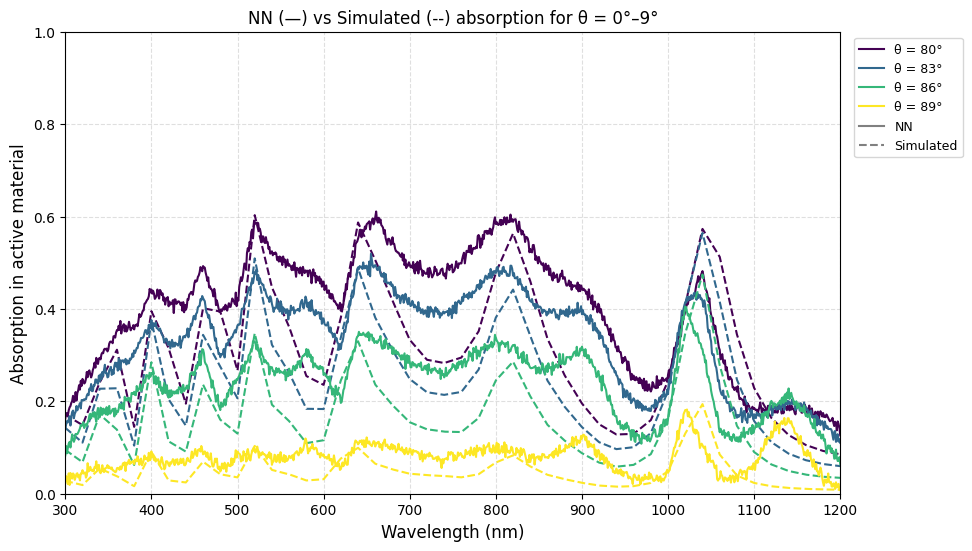

In [21]:
import matplotlib.cm as cm

lambda_nn = np.arange(300, 1201, 1)  # 901 points
angles_to_plot = range(80, 90, 3)
colors = cm.viridis(np.linspace(0, 1, len(angles_to_plot)))
 
fig, ax = plt.subplots(figsize=(10, 6))
 
for idx, i in enumerate(angles_to_plot):
    ax.plot(lambda_nn, A[0, i],     color=colors[idx], lw=1.5, linestyle="-",
            label=f"θ = {i}°" if idx == 0 else f"θ = {i}°")
    ax.plot(lambda_nn, A_new[0, i], color=colors[idx], lw=1.5, linestyle="--")
 
# ── Legend: one entry per angle (color), plus linestyle guide ─────────────
angle_lines = [plt.Line2D([0], [0], color=colors[idx], lw=1.5,
               label=f"θ = {i}°") for idx, i in enumerate(angles_to_plot)]
style_lines  = [plt.Line2D([0], [0], color="gray", lw=1.5, linestyle="-",  label="NN"),
                plt.Line2D([0], [0], color="gray", lw=1.5, linestyle="--", label="Simulated")]
 
ax.legend(handles=angle_lines + style_lines,
          bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
 
ax.set_xlabel("Wavelength (nm)", fontsize=12)
ax.set_ylabel("Absorption in active material", fontsize=12)
ax.set_title("NN (—) vs Simulated (--) absorption for θ = 0°–9°", fontsize=12)
ax.set_xlim(300, 1200)
ax.set_ylim(0, 1)
ax.grid(True, linestyle="--", alpha=0.4)

═══ Global error metrics ═══════════════════════════════
  MAE                    : 0.0561
  RMSE                   : 0.0791
  Mean relative error    : 21.95 %

  Mean spectral integral error : 25.09 nm
  Mean relative integral error : 9.09 %
  Max  relative integral error : 67.15 %  at θ = 89°


/tmp/ipykernel_203940/4057071360.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_nn  = np.trapz(A_nn,  lambda_nn, axis=1)   # shape (90,)
/tmp/ipykernel_203940/4057071360.py:32: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_sim = np.trapz(A_sim, lambda_nn, axis=1)   # shape (90,)


Text(0.5, 0.98, 'A (NN) vs A_new (Simulated) — MAE=0.0561, RMSE=0.0791, Mean rel. error=21.9%')

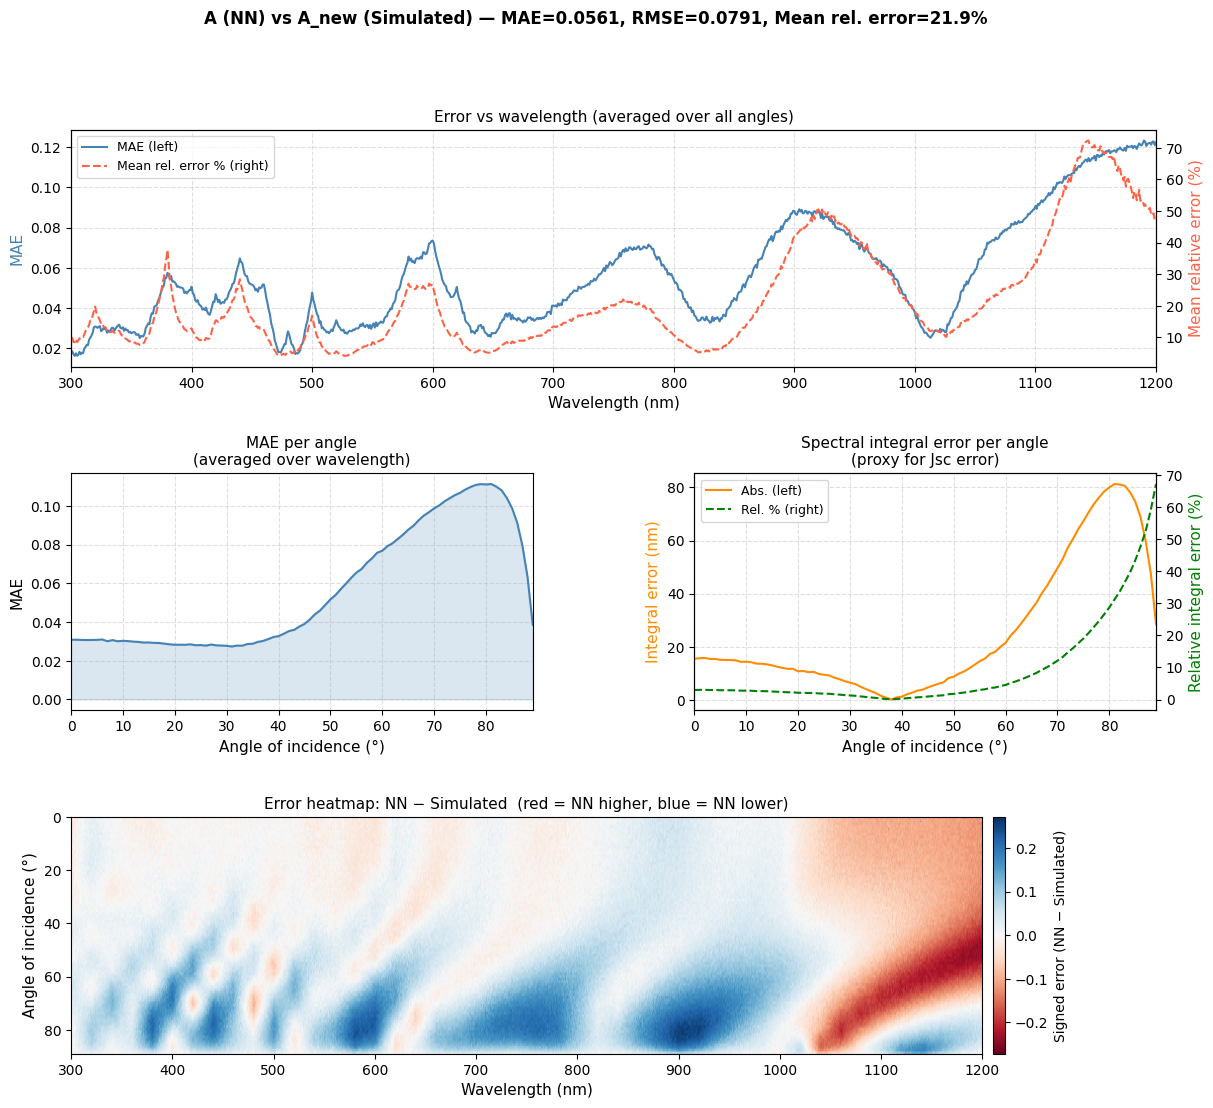

In [22]:
import matplotlib.gridspec as gridspec
 
lambda_nn  = np.arange(300, 1201, 1)   # 901 points
epsilon    = 1e-6                        # avoid division by zero in relative error
 
# ── Squeeze batch dim for convenience: (90, 901) ──────────────────────────
A_nn  = np.array(A[0])      # shape (90, 901)
A_sim = np.array(A_new[0])  # shape (90, 901)

# # ── consider single angle only ──────────────────────────
# A_nn  = A_nn[0]     # shape (, 901)
# A_sim = A_sim[0]  # shape (, 901)
 
# ═══════════════════════════════════════════════════════════════════════════
# 1. Scalar global metrics
# ═══════════════════════════════════════════════════════════════════════════
diff      = A_nn - A_sim
mae       = np.mean(np.abs(diff))
rmse      = np.sqrt(np.mean(diff**2))
rel_error = np.abs(diff) / (A_sim + epsilon)   # shape (90, 901)
mean_rel  = np.mean(rel_error) * 100           # in %
 
print("═══ Global error metrics ═══════════════════════════════")
print(f"  MAE                    : {mae:.4f}")
print(f"  RMSE                   : {rmse:.4f}")
print(f"  Mean relative error    : {mean_rel:.2f} %")
 
# ═══════════════════════════════════════════════════════════════════════════
# 2. Spectral integral error per angle  (most relevant for Jsc)
# ═══════════════════════════════════════════════════════════════════════════
integral_nn  = np.trapz(A_nn,  lambda_nn, axis=1)   # shape (90,)
integral_sim = np.trapz(A_sim, lambda_nn, axis=1)   # shape (90,)
integral_err = np.abs(integral_nn - integral_sim)
rel_integral_err = integral_err / (integral_sim + epsilon) * 100
 
print(f"\n  Mean spectral integral error : {np.mean(integral_err):.2f} nm")
print(f"  Mean relative integral error : {np.mean(rel_integral_err):.2f} %")
print(f"  Max  relative integral error : {np.max(rel_integral_err):.2f} %  at θ = {np.argmax(rel_integral_err)}°")
 
# ═══════════════════════════════════════════════════════════════════════════
# 3. MAE per angle  (90 values)
# ═══════════════════════════════════════════════════════════════════════════
mae_per_angle = np.mean(np.abs(diff), axis=1)   # shape (90,)
 
# ═══════════════════════════════════════════════════════════════════════════
# 4. MAE per wavelength  (901 values)
# ═══════════════════════════════════════════════════════════════════════════
mae_per_wl = np.mean(np.abs(diff), axis=0)      # shape (901,)
rel_per_wl = np.mean(rel_error,    axis=0) * 100
 
# ═══════════════════════════════════════════════════════════════════════════
# 5. Signed error map  (heatmap over angle × wavelength)
# ═══════════════════════════════════════════════════════════════════════════
 
# ── Figure layout ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 12))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)
 
ax1 = fig.add_subplot(gs[0, :])   # full-width: MAE + rel error vs wavelength
ax2 = fig.add_subplot(gs[1, 0])   # MAE per angle
ax3 = fig.add_subplot(gs[1, 1])   # spectral integral error per angle
ax4 = fig.add_subplot(gs[2, :])   # heatmap
 
# ── Panel 1: MAE and relative error vs wavelength ─────────────────────────
ax1b = ax1.twinx()
ax1.plot(lambda_nn, mae_per_wl,  color="steelblue", lw=1.5, label="MAE (left)")
ax1b.plot(lambda_nn, rel_per_wl, color="tomato",    lw=1.5, linestyle="--",
          label="Mean rel. error % (right)")
ax1.set_xlabel("Wavelength (nm)", fontsize=11)
ax1.set_ylabel("MAE", fontsize=11, color="steelblue")
ax1b.set_ylabel("Mean relative error (%)", fontsize=11, color="tomato")
ax1.set_xlim(300, 1200)
ax1.set_title("Error vs wavelength (averaged over all angles)", fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.4)
lines1  = ax1.get_lines()  + ax1b.get_lines()
labels1 = [l.get_label() for l in lines1]
ax1.legend(lines1, labels1, fontsize=9, loc="upper left")
 
# ── Panel 2: MAE per angle ─────────────────────────────────────────────────
ax2.plot(np.arange(90), mae_per_angle, color="steelblue", lw=1.5)
ax2.fill_between(np.arange(90), mae_per_angle, alpha=0.2, color="steelblue")
ax2.set_xlabel("Angle of incidence (°)", fontsize=11)
ax2.set_ylabel("MAE", fontsize=11)
ax2.set_title("MAE per angle\n(averaged over wavelength)", fontsize=11)
ax2.set_xlim(0, 89)
ax2.grid(True, linestyle="--", alpha=0.4)
 
# ── Panel 3: spectral integral error per angle ────────────────────────────
ax3b = ax3.twinx()
ax3.plot(np.arange(90), integral_err,     color="darkorange", lw=1.5, label="Abs. (left)")
ax3b.plot(np.arange(90), rel_integral_err, color="green",     lw=1.5,
          linestyle="--", label="Rel. % (right)")
ax3.set_xlabel("Angle of incidence (°)", fontsize=11)
ax3.set_ylabel("Integral error (nm)", fontsize=11, color="darkorange")
ax3b.set_ylabel("Relative integral error (%)", fontsize=11, color="green")
ax3.set_title("Spectral integral error per angle\n(proxy for Jsc error)", fontsize=11)
ax3.set_xlim(0, 89)
ax3.grid(True, linestyle="--", alpha=0.4)
lines3  = ax3.get_lines()  + ax3b.get_lines()
labels3 = [l.get_label() for l in lines3]
ax3.legend(lines3, labels3, fontsize=9, loc="upper left")
 
# ── Panel 4: signed error heatmap (NN − simulated) ────────────────────────
im  = ax4.imshow(diff, aspect="auto", cmap="RdBu",
                 vmin=-np.max(np.abs(diff)), vmax=np.max(np.abs(diff)),
                 extent=[300, 1200, 89, 0], origin="upper")
cbar = fig.colorbar(im, ax=ax4, pad=0.01)
cbar.set_label("Signed error (NN − Simulated)", fontsize=10)
ax4.set_xlabel("Wavelength (nm)", fontsize=11)
ax4.set_ylabel("Angle of incidence (°)", fontsize=11)
ax4.set_title("Error heatmap: NN − Simulated  (red = NN higher, blue = NN lower)", fontsize=11)
 
fig.suptitle(f"A (NN) vs A_new (Simulated) — MAE={mae:.4f}, RMSE={rmse:.4f}, "
             f"Mean rel. error={mean_rel:.1f}%", fontsize=12, fontweight="bold")

In [23]:
angles = np.arange(0.0, 90.0, 1.0) 
# ── Squeeze batch dim for convenience: (90, 901) ──────────────────────────
A_nn  = np.array(A[0])      # shape (90, 901)
A_sim = np.array(A_new[0])  # shape (90, 901)

# ── consider single angle only ──────────────────────────
i = 55
A_nn  = A_nn[i]     # shape (, 901)
A_sim = A_sim[i]  # shape (, 901)
 
# ═══════════════════════════════════════════════════════════════════════════
# 1. Scalar global metrics
# ═══════════════════════════════════════════════════════════════════════════
diff      = A_nn - A_sim
mae       = np.mean(np.abs(diff))
rmse      = np.sqrt(np.mean(diff**2))
rel_error = np.abs(diff) / (A_sim + epsilon)   # shape (90, 901)
mean_rel  = np.mean(rel_error) * 100           # in %
 
print("═══ Global error metrics for angle " + str(angles[i])+" degree ═══════════════════════════════")
print(f"  MAE                    : {mae:.4f}")
print(f"  RMSE                   : {rmse:.4f}")
print(f"  Mean relative error    : {mean_rel:.2f} %")

═══ Global error metrics for angle 55.0 degree ═══════════════════════════════
  MAE                    : 0.0655
  RMSE                   : 0.0858
  Mean relative error    : 15.64 %
